In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!apt-get install unrar
!pip install wfdb
!unrar x "/content/drive/MyDrive/ecg_dataset.rar" /content/ecg_dataset/

Strumieniowane dane wyjściowe obcięte do 5000 ostatnich wierszy.
Extracting  /content/ecg_dataset/train/ecg_train_1876.json                52%  OK 
Extracting  /content/ecg_dataset/train/ecg_train_1876.png                 52%  OK 
Extracting  /content/ecg_dataset/train/ecg_train_1877.dat                 52%  OK 
Extracting  /content/ecg_dataset/train/ecg_train_1877.hea                 52%  OK 
Extracting  /content/ecg_dataset/train/ecg_train_1877.json                52%  OK 
Extracting  /content/ecg_dataset/train/ecg_train_1877.png                 52%  OK 
Extracting  /content/ecg_dataset/train/ecg_train_1878.dat                 52%  OK 
Extracting  /content/ecg_dataset/train/ecg_train_1878.hea                 52%  OK 
Extracting  /content/ecg_dataset/train/ecg_train_1878.json                52%  OK 
Extracting  /content/ecg_dataset/train/ecg_train_1878.png                 52%  OK 
Extracting  /co

In [106]:
import os
import torch
from torch.utils.data import Dataset
import wfdb
import cv2
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt


class ECGDataset(Dataset):

    def __init__(self, data_dir, plot=False, train=False):
        self.data_dir = data_dir

        self.records = sorted([
            f.replace(".png","")
            for f in os.listdir(data_dir)
            if f.endswith(".png")
        ])
        self.plot = plot
        self.train = train


    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        record_name = self.records[idx]

        # image
        img_path = os.path.join(self.data_dir, record_name + ".png")
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # signal
        if self.train:
            record = wfdb.rdrecord(os.path.join(self.data_dir, record_name))
            signal = record.p_signal

        img = torch.tensor(img).permute(2,0,1).float()
        if self.train:
            signal = torch.tensor(signal).float()

        image = self.preprocess_img(img)

        leads = self.get_leads(image)

        if self.plot:
            for name, mask in leads.items():
                plt.imshow(mask, cmap="gray")
                plt.title(f"Lead {name}")
                plt.axis("off")
                plt.show()
        if self.train:
            return leads, signal
        return leads

    def preprocess_img(self, image):
        # Convert tensor to numpy array and ensure correct format
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).numpy()  # C,H,W -> H,W,C
        # Ensure uint8 dtype for OpenCV (0-255 range)
        if image.dtype != np.uint8:
            image = (image * 255).astype(np.uint8) if image.max() <= 1.0 else image.astype(np.uint8)

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Usunięcie szumu
        blur = cv2.GaussianBlur(gray, (5,5), 0)
        # Poprawa kontrastu
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        norm = clahe.apply(blur)

        # 🔥 NOWE: WYRYWALNIANIE LINII ECG DLA LEPSZEJ DETEKCJI
        edges = cv2.Canny(norm, 50, 150)

        # 🔥 PRECYZYJNA DETEKCJA LINII HoughLinesP (dla ECG traces)
        lines = cv2.HoughLinesP(
            edges,
            1, np.pi/180,
            threshold=50,      # Zmniejszone dla cienkich linii ECG
            minLineLength=50,  # Krótsze linie ECG
            maxLineGap=15      # Większa tolerancja przerw
        )

        # 🔥 OBLICZ ŚREDNI KĄT LINII ECG
        if lines is not None and len(lines) > 5:
            angles = []
            for line in lines:
                x1, y1, x2, y2 = line[0]
                angle = np.arctan2(y2-y1, x2-x1) * 180 / np.pi
                if abs(angle) < 45:  # Tylko poziome linie (ECG traces)
                    angles.append(angle)

            if angles:
                rotation_angle = np.median(angles)
                # print(f"🔄 Rotacja ECG: {rotation_angle:.2f}°")
            else:
                rotation_angle = 0
        else:
            rotation_angle = 0

        # 🔥 PIERWSZA ROTACJA: WYRÓWANIE SIATKI (minAreaRect)
        grid_edges = cv2.Canny(norm, 100, 200)  # Silniejsze krawędzie siatki
        coords = np.column_stack(np.where(grid_edges > 0))
        if len(coords) > 5:
            rect = cv2.minAreaRect(coords)
            angle = rect[-1]
            if angle < -45:
                angle = -(90 + angle)
            else:
                angle = -angle
        else:
            angle = 0

        (h, w) = image.shape[:2]
        center = (w // 2, h // 2)

        # Rotacja 1: wyrównanie siatki
        M_grid = cv2.getRotationMatrix2D(center, angle, 1.0)
        image_rotated = cv2.warpAffine(image, M_grid, (w, h),
                                    flags=cv2.INTER_CUBIC,
                                    borderMode=cv2.BORDER_REPLICATE)

        # 🔥 Rotacja 2: PRECYZYJNE WYRÓWANIE LINII ECG
        gray_rot = cv2.cvtColor(image_rotated, cv2.COLOR_RGB2GRAY)
        edges_rot = cv2.Canny(gray_rot, 50, 150)
        lines_rot = cv2.HoughLinesP(edges_rot, 1, np.pi/180, 30, 30, 10)

        if lines_rot is not None and len(lines_rot) > 10:
            angles_rot = []
            for line in lines_rot[:20]:  # Pierwsze 20 linii
                x1, y1, x2, y2 = line[0]
                angle_rot = np.arctan2(y2-y1, x2-x1) * 180 / np.pi
                if abs(angle_rot) < 10:  # Bardzo małe kąty korekty
                    angles_rot.append(angle_rot)

            if angles_rot:
                fine_rotation = np.median(angles_rot)
                M_fine = cv2.getRotationMatrix2D(center, fine_rotation, 1.0)
                undistorted = cv2.warpAffine(image_rotated, M_fine, (w, h),
                                        flags=cv2.INTER_CUBIC,
                                        borderMode=cv2.BORDER_REPLICATE)
                # print(f"🔧 Fine-tuning rotacji: {fine_rotation:.3f}°")
            else:
                undistorted = image_rotated
        else:
            undistorted = image_rotated

        # Reszta bez zmian...
        gray2 = cv2.cvtColor(undistorted, cv2.COLOR_RGB2GRAY)
        _, mask = cv2.threshold(gray2, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        # Przytnij maskę: 3/50 szerokości z lewej i prawej
        h, w = mask.shape
        left_margin = int(w * 3 / 50)
        right_margin = int(w * 3 / 50)
        mask_cropped = mask[:, left_margin:w - right_margin]

        kernel = np.ones((3,3), np.uint8)
        mask_clean = cv2.morphologyEx(mask_cropped, cv2.MORPH_OPEN, kernel)
        mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)

        # Normalizacja: 255 → 1, reszta → 0
        mask_binary = (mask_clean == 255).astype(np.uint8)

        return mask_binary


    def get_leads(self, image):
        row_sums = []

        for i in range(image.shape[0]):
            row_sum = np.sum(image[i, :])
            row_sums.append(row_sum)
        row_sums = row_sums[2:]

        row_sums_np = np.array(row_sums)

        # ignorujemy początek maski (np. pierwsze 100 wierszy)
        ignore_top = 100
        row_sums_filtered = row_sums_np.copy()
        row_sums_filtered[:ignore_top] = 0

        # znajdź wszystkie lokalne maksima
        peaks, _ = find_peaks(row_sums_filtered, distance=50)

        middle_indices = []

        # wybierz 4 największe globalne maksima
        if len(peaks) < 4:
            print(f"⚠️ Warning: Only {len(peaks)} peaks found, using fallback grid")
            # Fallback: equal 6-row division
            h = image.shape[0]
            row_height = h // 6
            y_positions = [i * row_height for i in range(7)]
        else:
            peak_values = row_sums_filtered[peaks]
            top4_idx = peaks[np.argsort(peak_values)[-4:]]
            top4_idx = np.sort(top4_idx)

            middle_indices = []
            for i in range(len(top4_idx)-1):
                middle = (top4_idx[i] + top4_idx[i+1]) // 2
                middle_indices.append(middle)

        # wybieramy 3 indeksy pośrednie (między maksimami 1-2, 2-3, 3-4)
        # SAFETY CHECK: Ensure we have at least 2 middle indices
        if len(middle_indices) < 2:
            print(f"⚠️ Warning: Only {len(middle_indices)} middle indices, using fallback")
            h = image.shape[0]
            row_height = h // 6
            y_positions = [i * row_height for i in range(7)]
        else:
            first = middle_indices[0] - (middle_indices[1] - middle_indices[0])
            middle_indices.insert(0, first)
            last = middle_indices[-1] + (middle_indices[-1] - middle_indices[-2])
            middle_indices.append(last)
            y_positions = middle_indices

        y = y_positions

        y.insert(0, 0)
        y.append(image.shape[0])

        w = image.shape[1]
        x_positions = [w//4, w//2, 3*w//4]
        x = x_positions
        x.insert(0, 0)
        x.append(image.shape[1])

        lead_areas = []

        for i in range(len(x)-1):
            for j in range(len(y)-1):
                lead_area = image[y[j]:y[j+1], x[i]:x[i+1]]
                lead_areas.append(lead_area)

        lead_areas_final = lead_areas.copy()

        # ✅ POPRAWKA: Usuwaj TYLKO gdy mamy 18 obszarów (normalny grid)
        if len(lead_areas_final) == 24:
            # Standardowy grid 6x3 = 18 obszarów, usuwamy 12 → zostaje 6 precyzyjnych leadów
            remove_indices = [23, 22, 18, 17, 16, 12, 11, 10, 6, 5, 4, 0]
            for idx in sorted(remove_indices, reverse=True):  # Odwrotnie aby nie przesuwać indeksów
                if idx < len(lead_areas_final):
                    lead_areas_final.pop(idx)
        else:
            # Fallback: weź tylko 12 środkowych obszarów
            print(f"⚠️ Fallback: resizing {len(lead_areas_final)} → 12 lead areas")
            if len(lead_areas_final) >= 12:
                lead_areas_final = lead_areas_final[len(lead_areas_final)//4 : -len(lead_areas_final)//4]
            else:
                # Ekstremalny fallback - powtórz pierwszy lead
                lead_areas_final = [lead_areas_final[0]] * 12

        lead_names = [
            "I", "II", "III", "AVR", "AVL", "AVF",
            "V1", "V2", "V3", "V4", "V5", "V6"
        ]

        # ZMIANA assert na safe check
        if len(lead_areas_final) != len(lead_names):
            print(f"⚠️ Mismatch: {len(lead_areas_final)} areas vs {len(lead_names)} names")
            # Uzupełnij brakujące lub obetnij nadmiar
            if len(lead_areas_final) < len(lead_names):
                lead_areas_final += [lead_areas_final[-1]] * (len(lead_names) - len(lead_areas_final))
            else:
                lead_areas_final = lead_areas_final[:len(lead_names)]

        assert len(lead_names) == len(lead_areas_final), f"Final mismatch: {len(lead_names)} vs {len(lead_areas_final)}"

        lead_dict = {}
        for i, lead_mask in enumerate(lead_areas_final):
            lead_dict[lead_names[i]] = lead_mask

        return lead_dict



In [94]:
dataset = ECGDataset("/content/ecg_dataset/train", plot = True)

🔄 Rotacja ECG: 0.00°
🔧 Fine-tuning rotacji: 0.000°


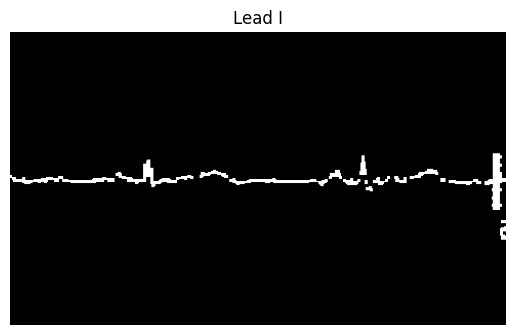

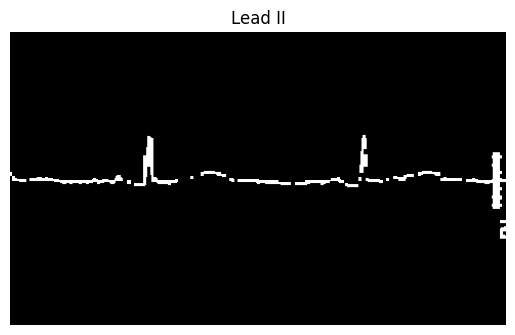

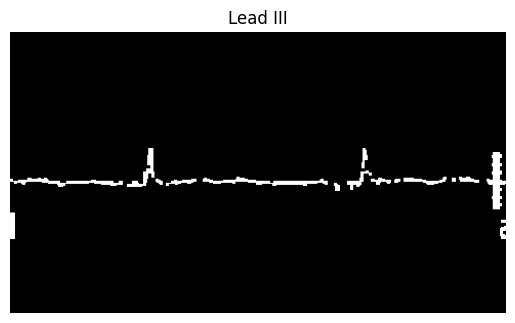

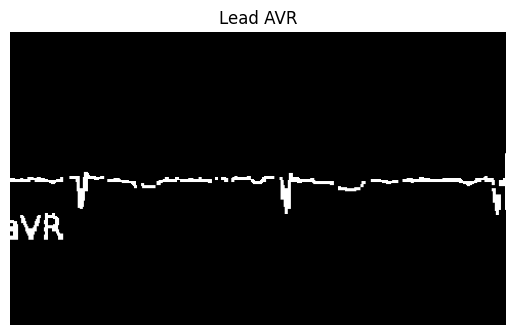

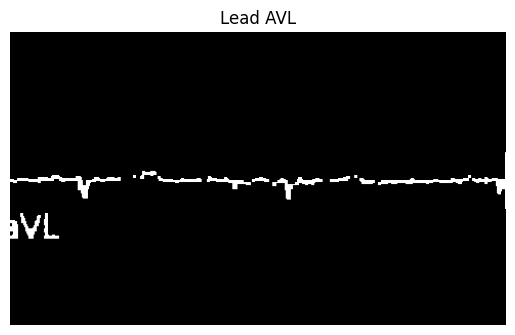

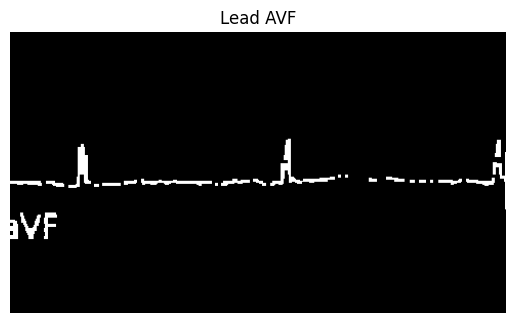

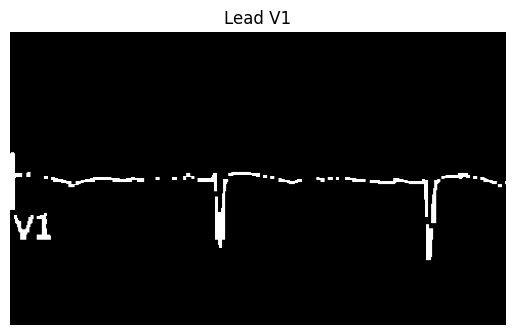

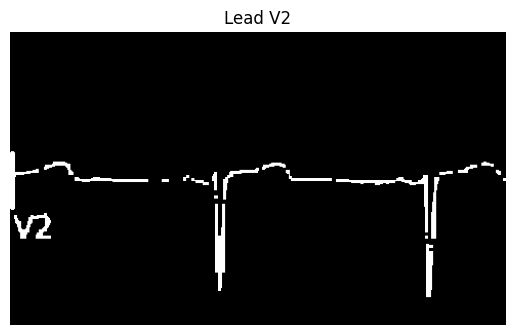

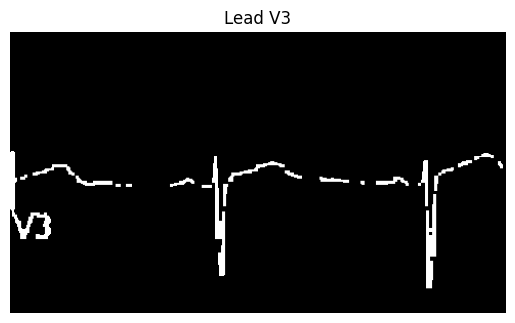

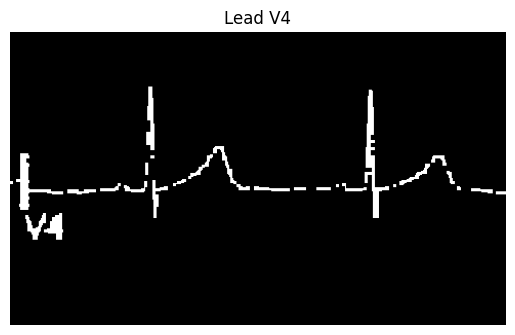

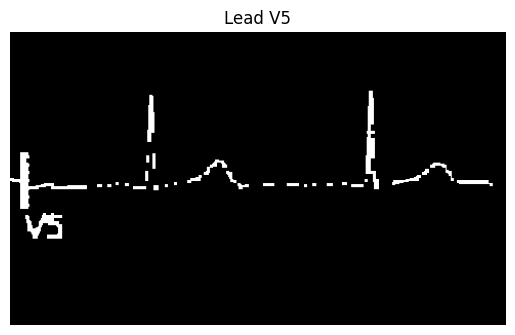

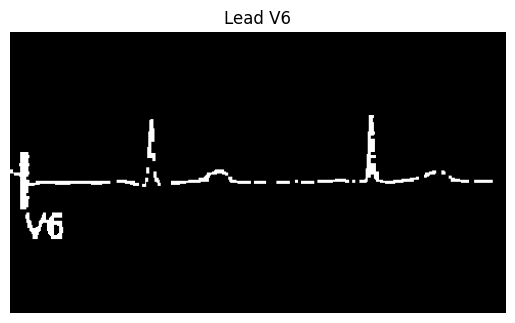

In [99]:
img = dataset[3]

In [107]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# 🔥 CNN + LSTM dla ekstrakcji sygnałów ECG z obrazów leadów
class ECGSignalNet(nn.Module):
    def __init__(self, input_channels=1, sequence_length=726, target_length=1250):
        super(ECGSignalNet, self).__init__()

        # CNN dla ekstrakcji cech z obrazów leadów (H, W)
        self.cnn = nn.Sequential(
            # Input: (1, H, W) -> (32, H/2, W/2)
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # (32, H/4, W/4) -> (64, H/8, W/8)
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Global Average Pooling -> (64,)
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )

        # CNN feature extractor size (dostosuj po teście)
        cnn_features = 64

        # LSTM dla modelowania sekwencji czasowej
        self.lstm = nn.LSTM(cnn_features, 128, num_layers=2,
                           batch_first=True, bidirectional=True)

        # Regresja sygnału ECG (1250 próbek @ 500Hz)
        self.regressor = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, target_length)
        )

    def forward(self, x):
        # x: (batch, 1, H, W) - obrazy leadów
        batch_size = x.shape[0]

        # CNN feature extraction
        cnn_out = self.cnn(x)  # (batch, 64)

        # Reshape dla LSTM (batch, 1, 64)
        cnn_out = cnn_out.unsqueeze(1)

        # LSTM processing
        lstm_out, (h_n, c_n) = self.lstm(cnn_out)  # (batch, 1, 256)
        lstm_out = lstm_out[:, -1, :]  # last timestep (batch, 256)

        # Regresja sygnału
        signal = self.regressor(lstm_out)  # (batch, 1250)

        return signal

# Dataset wrapper dla obrazów leadów
class LeadImageDataset(torch.utils.data.Dataset):
    def __init__(self, leads_dict, signals=None, target_length=1250):
        self.leads_dict = leads_dict  # {record_name: {lead_name: mask}}
        self.signals = signals  # train only: {record_name: signal_array}
        self.target_length = target_length
        self.records = list(leads_dict.keys())

    def __len__(self):
        return len(self.records) * 12  # 12 leadów per record

    def __getitem__(self, idx):
        record_idx = idx // 12
        lead_idx = idx % 12

        record_name = self.records[record_idx]
        lead_name = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                    'V1', 'V2', 'V3', 'V4', 'V5', 'V6'][lead_idx]

        # Obraz leada (H, W) -> (1, H, W)
        lead_image = self.leads_dict[record_name][lead_name]
        lead_tensor = torch.tensor(lead_image, dtype=torch.float32).unsqueeze(0)

        if self.signals is not None:
            # Train: ground truth signal (interpolated to 1250)
            gt_signal = self.signals[record_name][lead_idx]
            gt_tensor = torch.tensor(gt_signal, dtype=torch.float32)
            return lead_tensor, gt_tensor

        return lead_tensor

# Trenowanie
def train_model():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️ Using device: {device}")

    # 1. TRAIN DATASET
    train_dataset = ECGDataset("/content/ecg_dataset/train", train=True)
    train_leads = {}
    train_signals = {}

    print("Ładowanie train dataset...")
    for i in tqdm(range(len(train_dataset))):
        leads, signal = train_dataset[i]
        record_name = train_dataset.records[i]
        train_leads[record_name] = leads
        train_signals[record_name] = signal.numpy().T  # (12 leads, 1250)

    train_ds = LeadImageDataset(train_leads, train_signals)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    # 2. TEST DATASET
    test_dataset = ECGDataset("/content/ecg_dataset/test", train=False)
    test_leads = {}

    print("Ładowanie test dataset...")
    for i in tqdm(range(len(test_dataset))):
        leads = test_dataset[i]
        record_name = test_dataset.records[i]
        test_leads[record_name] = leads

    test_ds = LeadImageDataset(test_leads)

    # 3. MODEL + OPTIMIZER
    model = ECGSignalNet().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # 4. TRENING
    model.train()
    epochs = 50

    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (images, targets) in enumerate(tqdm(train_loader)):
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            predictions = model(images)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}")

    # 5. PREDYKCJA TEST
    model.eval()
    submission_dict = {}

    with torch.no_grad():
        test_loader = DataLoader(test_ds, batch_size=64)
        for batch_idx, images in enumerate(tqdm(test_loader)):
            images = images.to(device)
            predictions = model(images)

            # Zapisz predykcje
            for i, pred in enumerate(predictions.cpu().numpy()):
                global_idx = batch_idx * 64 + i
                record_idx = global_idx // 12
                lead_idx = global_idx % 12

                record_name = list(test_leads.keys())[record_idx]
                lead_name = ['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6'][lead_idx]

                key = f"{record_name}_{lead_name}"
                submission_dict[key] = pred.numpy().astype(np.float32)

    # 6. ZAPIS SUBMISSION
    np.savez('submission_nn.npz', **submission_dict)
    print(f"✅ Predykcje zapisane: submission_nn.npz ({len(submission_dict)} leadów)")

    return model, submission_dict

# URUCHOMIENIE
if __name__ == "__main__":
    model, predictions = train_model()


🖥️ Using device: cpu
Ładowanie train dataset...


  1%|          | 23/3000 [01:03<2:17:19,  2.77s/it]


KeyboardInterrupt: 

## 2

In [55]:
# Iterate through entire dataset and store results
all_leads = {}
# all_signals = {}  # Changed to dict to match all_leads structure

# dataset = ECGDataset("/content/ecg_dataset/train", plot=False)
dataset = ECGDataset("/content/ecg_dataset/test", plot=False)
print(f"Processing {len(dataset)} records...")

for idx in range(len(dataset)):
    # leads, signal = dataset[idx]
    leads = dataset[idx]

    record_name = dataset.records[idx]
    all_leads[record_name] = leads
    # all_signals[record_name] = signal  # Now both are dicts with string keys

    if idx % 10== 0:
        print(f"Processed {idx}/{len(dataset)} records")

print(f"✅ Completed! Stored {len(all_leads)} records.")


Processing 500 records...
Processed 0/500 records
Processed 10/500 records
Processed 20/500 records
Processed 30/500 records
Processed 40/500 records
Processed 50/500 records
Processed 60/500 records
Processed 70/500 records
Processed 80/500 records
Processed 90/500 records
Processed 100/500 records
Processed 110/500 records
Processed 120/500 records
Processed 130/500 records
Processed 140/500 records
Processed 150/500 records
Processed 160/500 records
Processed 170/500 records
Processed 180/500 records
Processed 190/500 records
Processed 200/500 records
Processed 210/500 records
Processed 220/500 records
Processed 230/500 records
Processed 240/500 records
Processed 250/500 records
Processed 260/500 records
Processed 270/500 records
Processed 280/500 records
Processed 290/500 records
Processed 300/500 records
Processed 310/500 records
Processed 320/500 records
Processed 330/500 records
Processed 340/500 records
Processed 350/500 records
Processed 360/500 records
Processed 370/500 recor

In [56]:
def extract_lead_signal(lead_mask):
    """Ekstrakuje 1D sygnał z maski leada (kolumna -> mediana Y pikseli białych)"""
    h, w = lead_mask.shape

    signals_y = []
    for x in range(w):
        white_pixels_y = np.where(lead_mask[:, x] > 0)[0]
        if len(white_pixels_y) > 0:
            y_median = np.median(white_pixels_y)
            signals_y.append(y_median)
        else:
            signals_y.append(np.nan)

    return np.array(signals_y)

In [57]:
all_signals = {}  # record_name -> {lead_name: signal}

print("Ekstrakcja sygnałów dla wszystkich 500 rekordów testowych...")

for record_idx, record_name in enumerate(dataset.records):
    record_leads = all_leads[record_name]  # słownik leadów dla tego rekordu

    record_signals = {}
    for lead_name, lead_mask in record_leads.items():
        signal = extract_lead_signal(lead_mask)
        record_signals[lead_name] = signal

    all_signals[record_name] = record_signals

    if record_idx % 50 == 0:
        print(f"Processed {record_idx}/500 records")

print(f"✅ Ekstrakcja zakończona! {len(all_signals)} rekordów.")

# Sprawdź pierwszy rekord
sample_record = list(all_signals.keys())[0]
print(f"\nPrzykład rekordu {sample_record}:")
for lead_name in all_signals[sample_record]:
    signal = all_signals[sample_record][lead_name]
    print(f"  {lead_name}: {len(signal)} próbek, {np.sum(~np.isnan(signal))} pikseli")

Ekstrakcja sygnałów dla wszystkich 500 rekordów testowych...
Processed 0/500 records
Processed 50/500 records
Processed 100/500 records
Processed 150/500 records
Processed 200/500 records
Processed 250/500 records
Processed 300/500 records
Processed 350/500 records
Processed 400/500 records
Processed 450/500 records
✅ Ekstrakcja zakończona! 500 rekordów.

Przykład rekordu ecg_test_0001:
  I: 726 próbek, 726 pikseli
  II: 726 próbek, 725 pikseli
  III: 726 próbek, 726 pikseli
  AVR: 726 próbek, 725 pikseli
  AVL: 726 próbek, 724 pikseli
  AVF: 726 próbek, 723 pikseli
  V1: 726 próbek, 726 pikseli
  V2: 726 próbek, 726 pikseli
  V3: 726 próbek, 726 pikseli
  V4: 726 próbek, 726 pikseli
  V5: 726 próbek, 724 pikseli
  V6: 726 próbek, 725 pikseli


In [58]:
def normalize_signal(signal):
    """Normalizacja 0-1 dla sygnału z NaN"""
    valid = signal[~np.isnan(signal)]
    if len(valid) == 0:
        return np.zeros_like(signal)
    signal_norm = (signal - np.nanmin(valid)) / (np.nanmax(valid) - np.nanmin(valid))
    return signal_norm

In [59]:
# Normalizacja WSZYSTKICH rekordów i leadów
all_signals_normalized = {}

print("Normalizacja sygnałów dla 500 rekordów...")

for record_name, record_signals in all_signals.items():
    normalized_leads = {}
    for lead_name, signal in record_signals.items():
        normalized_leads[lead_name] = normalize_signal(signal)
    all_signals_normalized[record_name] = normalized_leads

    if list(all_signals_normalized.keys()).index(record_name) % 50 == 0:
        print(f"Normalized {len(all_signals_normalized)}/500 records")

print(f"✅ Normalizacja zakończona!")

# Sprawdź pierwszy rekord
sample_record = list(all_signals_normalized.keys())[0]
print(f"\nPrzykład: {sample_record}")
for lead_name, signal_norm in all_signals_normalized[sample_record].items():
    valid_points = np.sum(~np.isnan(signal_norm))
    print(f"  {lead_name}: {len(signal_norm)} próbek, zakres [0-1], {valid_points} punktów")

Normalizacja sygnałów dla 500 rekordów...
Normalized 1/500 records
Normalized 51/500 records
Normalized 101/500 records
Normalized 151/500 records
Normalized 201/500 records
Normalized 251/500 records
Normalized 301/500 records
Normalized 351/500 records
Normalized 401/500 records
Normalized 451/500 records
✅ Normalizacja zakończona!

Przykład: ecg_test_0001
  I: 726 próbek, zakres [0-1], 726 punktów
  II: 726 próbek, zakres [0-1], 725 punktów
  III: 726 próbek, zakres [0-1], 726 punktów
  AVR: 726 próbek, zakres [0-1], 725 punktów
  AVL: 726 próbek, zakres [0-1], 724 punktów
  AVF: 726 próbek, zakres [0-1], 723 punktów
  V1: 726 próbek, zakres [0-1], 726 punktów
  V2: 726 próbek, zakres [0-1], 726 punktów
  V3: 726 próbek, zakres [0-1], 726 punktów
  V4: 726 próbek, zakres [0-1], 726 punktów
  V5: 726 próbek, zakres [0-1], 724 punktów
  V6: 726 próbek, zakres [0-1], 725 punktów


/tmp/ipykernel_218/134907051.py:6: RuntimeWarning: invalid value encountered in divide
  signal_norm = (signal - np.nanmin(valid)) / (np.nanmax(valid) - np.nanmin(valid))


In [60]:
def normalize_to_mV_safe(signal, pixels_per_mm=25):
    """Bezpieczna konwersja: pixel → mV z ochroną przed NaN"""
    valid_signal = signal[~np.isnan(signal)]

    if len(valid_signal) == 0:
        return np.zeros_like(signal), 0, 0

    # Sprawdź wariancję - jeśli wszystkie wartości równe → brak sygnału
    if np.ptp(valid_signal) < 1e-6:  # peak-to-peak < 0.000001
        return np.zeros_like(signal), np.median(valid_signal), 0

    baseline = np.median(valid_signal)
    centered_signal = signal - baseline

    # Kalibracja 10mm = 1mV
    px_to_mV = 0.04  # 25px/mm * 0.1mV/mm * 10mm/mV
    signal_mV = centered_signal * px_to_mV

    return signal_mV, baseline, px_to_mV

In [61]:
print("Bezpieczna konwersja pixel → mV (v2)...")
all_signals_mV = {}

for record_idx, (record_name, record_signals) in enumerate(all_signals_normalized.items()):
    record_mV = {}
    for lead_name, signal_norm in record_signals.items():
        signal_mV, baseline, px_to_mV = normalize_to_mV_safe(signal_norm, 25)
        record_mV[lead_name] = signal_mV

    all_signals_mV[record_name] = record_mV

    if record_idx % 100 == 0:
        print(f"Processed {record_idx}/500")

print("✅ Bezpieczna konwersja zakończona!")

# Sprawdź poprawione zakresy
sample_record = list(all_signals_mV.keys())[5]
print(f"\nPoprawione zakresy mV dla {sample_record}:")
for lead_name, signal_mV in all_signals_mV[sample_record].items():
    valid_count = np.sum(~np.isnan(signal_mV))
    ptp = np.ptp(signal_mV)
    print(f"  {lead_name}: {signal_mV.min():.3f} .. {signal_mV.max():.3f} mV (ptp: {ptp:.3f}, valid: {valid_count})")

Bezpieczna konwersja pixel → mV (v2)...
Processed 0/500
Processed 100/500
Processed 200/500
Processed 300/500
Processed 400/500
✅ Bezpieczna konwersja zakończona!

Poprawione zakresy mV dla ecg_test_0006:
  I: -0.021 .. 0.019 mV (ptp: 0.040, valid: 484)
  II: -0.020 .. 0.020 mV (ptp: 0.040, valid: 484)
  III: -0.020 .. 0.020 mV (ptp: 0.040, valid: 484)
  AVR: -0.021 .. 0.019 mV (ptp: 0.040, valid: 484)
  AVL: -0.020 .. 0.020 mV (ptp: 0.040, valid: 484)
  AVF: -0.022 .. 0.018 mV (ptp: 0.040, valid: 484)
  V1: -0.020 .. 0.020 mV (ptp: 0.040, valid: 484)
  V2: -0.020 .. 0.020 mV (ptp: 0.040, valid: 484)
  V3: -0.020 .. 0.020 mV (ptp: 0.040, valid: 484)
  V4: -0.020 .. 0.020 mV (ptp: 0.040, valid: 484)
  V5: -0.021 .. 0.019 mV (ptp: 0.040, valid: 484)
  V6: -0.019 .. 0.021 mV (ptp: 0.040, valid: 484)


In [62]:
from scipy.interpolate import interp1d

def interpolate_500Hz(signal, original_length=726, target_samples=1250):
    """Interpolacja do standardowego 500Hz"""
    if len(signal) == 0:
        return np.zeros(target_samples, dtype=np.float32)

    valid_idx = ~np.isnan(signal)
    if np.sum(valid_idx) < 2:
        return np.zeros(target_samples, dtype=np.float32)

    x_old = np.arange(len(signal))[valid_idx]
    y_old = signal[valid_idx]

    x_new = np.linspace(0, len(signal)-1, target_samples)
    f = interp1d(x_old, y_old, kind='linear', bounds_error=False, fill_value='extrapolate')

    return f(x_new).astype(np.float32)

In [63]:
# FINALNA INTERPOLACJA
print("Interpolacja do 500Hz (1250 próbek/2.5s)...")
all_signals_final = {}

original_length = 726
target_samples = 1250

for record_name, record_mV in all_signals_mV.items():
    final_leads = {}
    for lead_name, signal_mV in record_mV.items():
        final_leads[lead_name] = interpolate_500Hz(signal_mV, original_length, target_samples)
    all_signals_final[record_name] = final_leads


print(f"✅ 500Hz interpolacja zakończona!")

Interpolacja do 500Hz (1250 próbek/2.5s)...
✅ 500Hz interpolacja zakończona!


In [64]:
import pandas as pd

# ## Eksport finalnych sygnałów 500Hz
signals_500Hz_df = pd.DataFrame(all_signals_final)
signals_500Hz_df.to_csv('ecg_leads_500Hz.csv', index=False)
print(f"\nZapisano: ecg_leads_500Hz.csv ({signals_500Hz_df.shape})")

# Sprawdź statystyki
print("\nStatystyki po interpolacji:")
print(signals_500Hz_df.describe())


Zapisano: ecg_leads_500Hz.csv ((12, 500))

Statystyki po interpolacji:
                                            ecg_test_0001  \
count                                                  12   
unique                                                 12   
top     [-0.0068501527, -0.0068501527, -0.006889524, -...   
freq                                                    1   

                                            ecg_test_0002  \
count                                                  12   
unique                                                 12   
top     [-0.0068433736, -0.0068433736, -0.0069054184, ...   
freq                                                    1   

                                            ecg_test_0003  \
count                                                  12   
unique                                                 12   
top     [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 8.205322e-...   
freq                                                    1   

          

In [65]:
submission_dict = {}
for record_name, leads in all_signals_final.items():
    for lead_name, signal in leads.items():
        key = f"{record_name}_{lead_name}"
        submission_dict[key] = signal

np.savez('submission.npz', **submission_dict)
print(f"✅ submission.npz UTWORZONY! {len(submission_dict)} sygnałów (500×12)")

# Weryfikacja
loaded = np.load('submission.npz')
print(f"Weryfikacja OK: {len(loaded.files)} plików, każdy {loaded[loaded.files[0]].shape}")

print(loaded)

✅ submission.npz UTWORZONY! 6000 sygnałów (500×12)
Weryfikacja OK: 6000 plików, każdy (1250,)
NpzFile 'submission.npz' with keys: ecg_test_0001_I, ecg_test_0001_II, ecg_test_0001_III, ecg_test_0001_AVR, ecg_test_0001_AVL...


In [66]:
# Wyświetl dane dla PIERWSZEGO rekordu (ecg_test_0001)
first_record_keys = [k for k in loaded.files if k.startswith('ecg_test_0401')]
print(f"\n📊 DANE REKORDU ecg_test_0001 ({len(first_record_keys)} leadów):")
print("=" * 80)

for i, key in enumerate(first_record_keys):
    signal = loaded[key]
    print(f"\n{key}:")
    print(f"  Kształt: {signal.shape}")
    print(f"  Zakres: {signal.min():.4f} .. {signal.max():.4f} mV")
    print(f"  Średnia: {signal.mean():.4f} mV")
    print(f"  Std dev: {signal.std():.4f} mV")
    print(f"  Pierwsze 10 próbek: {signal[:10]}")
    print(f"  Ostatnie 5 próbek:  {signal[-5:]}")

    if i >= 2:  # pokaż tylko pierwsze 3 leady
        print("  ... (pozostałe leady pominięte)")
        break

# Statystyki wszystkich leadów pierwszego rekordu
print(f"\n📈 SZYBKIE PODSUMOWANIE ecg_test_0001:")
print("-" * 50)
for key in first_record_keys[:6]:  # pierwsze 6 leadów
    signal = loaded[key]
    print(f"{key:15} | ptp: {np.ptp(signal):6.3f} mV | valid: {np.sum(~np.isnan(signal))} pts")



📊 DANE REKORDU ecg_test_0001 (12 leadów):

ecg_test_0401_I:
  Kształt: (1250,)
  Zakres: -0.0236 .. 0.0162 mV
  Średnia: -0.0007 mV
  Std dev: 0.0039 mV
  Pierwsze 10 próbek: [0.00026578 0.00026578 0.00026578 0.00026578 0.00026578 0.00026578
 0.00026578 0.00026578 0.00030313 0.0004573 ]
  Ostatnie 5 próbek:  [0.00951427 0.01105597 0.01271811 0.01446537 0.01621263]

ecg_test_0401_II:
  Kształt: (1250,)
  Zakres: -0.0217 .. 0.0180 mV
  Średnia: 0.0004 mV
  Std dev: 0.0043 mV
  Pierwsze 10 próbek: [0.00196078 0.00196078 0.00196078 0.00202358 0.00217523 0.00232688
 0.00235294 0.00235294 0.00237131 0.00244713]
  Ostatnie 5 próbek:  [-0.01339786 -0.01529349 -0.01710027 -0.01884425 -0.02058824]

ecg_test_0401_III:
  Kształt: (1250,)
  Zakres: -0.0040 .. 0.0349 mV
  Średnia: 0.0017 mV
  Std dev: 0.0059 mV
  Pierwsze 10 próbek: [0.00181818 0.00181818 0.00181818 0.00181818 0.00181818 0.00181818
 0.00181818 0.00181818 0.00175005 0.00146881]
  Ostatnie 5 próbek:  [0.0148299  0.01848606 0.01612752

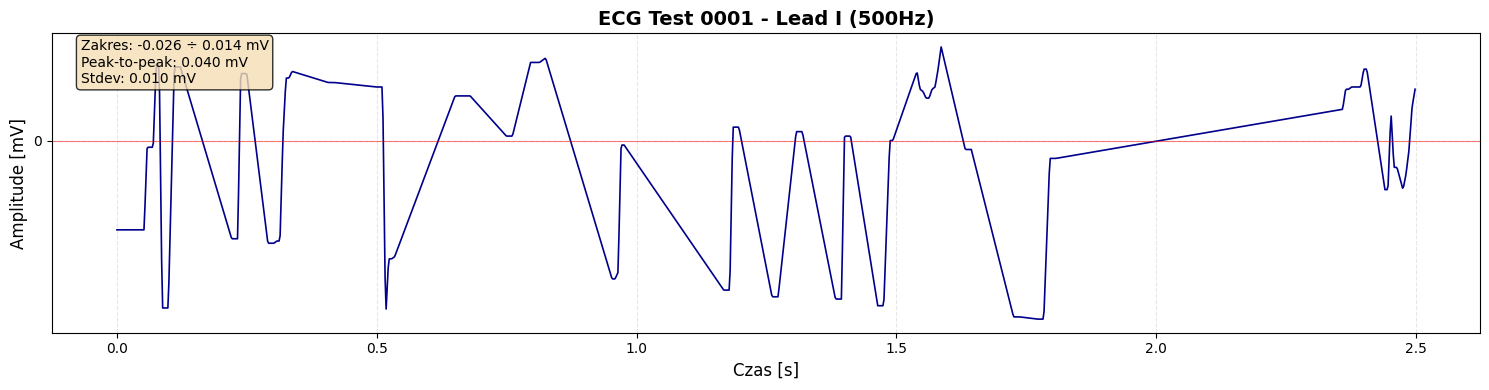

📊 Lead I statystyki:
  Długość: 1250 próbek (2.5s @ 500Hz)
  Zakres: -0.0262 .. 0.0138 mV
  Średnia: -0.0031 mV
  Peak-to-peak: 0.040 mV


In [67]:
import matplotlib.pyplot as plt
import numpy as np

# Wczytaj lead I z pierwszego rekordu
loaded = np.load('submission.npz')
lead_I_key = 'ecg_test_0005_I'
signal_I = loaded[lead_I_key]

# Czas w sekundach (500Hz = 0.002s/próbka)
time_seconds = np.arange(len(signal_I)) * 0.002  # 1250 próbek = 2.5s

# Wykres
plt.figure(figsize=(15, 4))
plt.plot(time_seconds, signal_I, linewidth=1.2, color='darkblue')
plt.title('ECG Test 0001 - Lead I (500Hz)', fontsize=14, fontweight='bold')
plt.xlabel('Czas [s]', fontsize=12)
plt.ylabel('Amplitude [mV]', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=0, color='red', linestyle='-', alpha=0.5, linewidth=0.8)

# Oznaczenia osi
plt.xticks(np.arange(0, 2.6, 0.5))
plt.yticks(np.arange(signal_I.min().round(), signal_I.max().round()+0.01, 0.01))

# Statystyki na wykresie
plt.text(0.02, 0.98, f'Zakres: {signal_I.min():.3f} ÷ {signal_I.max():.3f} mV\n'
                   f'Peak-to-peak: {np.ptp(signal_I):.3f} mV\n'
                   f'Stdev: {signal_I.std():.3f} mV',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"📊 Lead I statystyki:")
print(f"  Długość: {len(signal_I)} próbek (2.5s @ 500Hz)")
print(f"  Zakres: {signal_I.min():.4f} .. {signal_I.max():.4f} mV")
print(f"  Średnia: {signal_I.mean():.4f} mV")
print(f"  Peak-to-peak: {np.ptp(signal_I):.3f} mV")
